# Retrosynthesis with Synthon Priority Rules

The synthon subsystem ships a curated set of disconnection rules, used for building block synthonisation and library enumeration. The same rules can be handed to the MCTS planner as *priority rules*: a curated set that is tried on every node before the learned policy.

This tutorial loads the shipped disconnections with `synthon_priority_rules()`, shows what the loader does to them and what it leaves out, runs a search on a small drug molecule, and reads the applied chemistry back off the route.

Retrosynthetic planning itself is covered in the [retrosynthetic planning tutorial](05_Retrosynthetic_Planning.ipynb), the priority-rule mechanism with a hand-written rule set in the [priority rules tutorial](13_Priority_Rules.ipynb), and the disconnections themselves in the [synthon-based library design tutorial](17_Synthon_Based_Design.ipynb). Only the synthon-specific parts are explained here.

## Basic recommendations

1. Keep `cap=True`. Without it the disconnections propose purchasable compounds of the wrong class, and a search will happily end on one.

2. The default set is the acyclic rules plus the ring rules that carry a hand-authored reagent form. Load the macrocyclic half with `macro=True` for a macrocyclic target.

3. A priority rule enters the search with a prior of at least 1, against policy siblings well below it, so a small curated set changes the top of the tree far more than its size suggests. Compare against a `use_priority=False` run before reading anything into the result.

<div class="alert alert-info">
<b>Note</b>

"Synthon" names two different things in SynPlanner. Here it is a labelled fragment produced by a disconnection rule from `synplan.chem.synthon`. In the route clustering tutorial, `synthon_cgr` means a strategic bond inside a route and has nothing to do with these rules.
</div>

## 1. Set up input data

The planning components come from the same preset used in the planning tutorial: a policy network, the extracted reaction rules it ranks, and a building block set. The synthon disconnections need no download; they ship inside the package.

In [1]:
from synplan.utils.loading import download_preset

paths = download_preset("synplanner-gps", save_to="synplan_data")

reaction_rules_path = paths["reaction_rules"]
ranking_policy_network = paths["ranking_policy"]
building_blocks_path = paths["building_blocks"]

## 2. Loading search components

Building blocks, reaction rules and the ranking policy are loaded exactly as in the planning tutorial. Node evaluation uses the RDKit molecular-weight scorer, which is fast enough to keep this notebook short.

In [2]:
from synplan.utils.loading import (
    load_building_blocks,
    load_evaluation_function,
    load_policy_function,
    load_reaction_rules,
)

building_blocks = load_building_blocks(
    building_blocks_path, standardize=False, silent=False
)
reaction_rules = load_reaction_rules(reaction_rules_path)
policy_function = load_policy_function(weights_path=ranking_policy_network)

print(f"Building blocks: {len(building_blocks):,}")
print(f"Policy reaction rules: {len(reaction_rules):,}")

Building blocks: 186,868
Policy reaction rules: 11,235


In [3]:
from synplan.utils.config import RDKitEvaluationConfig

evaluation_function = load_evaluation_function(
    RDKitEvaluationConfig(score_function="weight")
)

## 3. The shipped disconnections as a priority set

`synthon_priority_rules()` reads the same `rules.json` the synthonisation CLI uses and returns a mapping from one source name to a list of `CanonicalRetroReactor` objects, which is the shape `Tree(priority_rules=...)` expects.

In [4]:
from synplan.chem.reaction.rules.synthon import (
    SYNTHON_SOURCE_NAME,
    synthon_priority_rules,
)

priority_rules = synthon_priority_rules()
synthon_rules = priority_rules[SYNTHON_SOURCE_NAME]

print(f"source name: {SYNTHON_SOURCE_NAME!r}")
print(f"rules loaded: {len(synthon_rules)}")
print(f"rule object: {type(synthon_rules[0]).__name__}")
print(f"first rule: {synthon_rules[0].rule_id} - {synthon_rules[0].rule_name}")

source name: 'synthon'
rules loaded: 108
rule object: CanonicalRetroReactor
first rule: R1.1 - Amine acylation


The key of that mapping becomes `rule_source` on every node the set produces, and its counters land in `tree.stats.per_priority_source["synthon"]`. Several sets can be passed in one dict, and the statistics keep them apart.

Each rule keeps the metadata of its `rules.json` record. The record is the place to read it from, joined on `rule_id`.

`rules_frame` does that join for you and returns a `ChemFrame`: a pandas frame that draws any chython object it holds — here the rule itself — when a notebook displays it. `.df` gives the plain frame back with the objects intact, so every pandas verb still applies.

In [5]:
from synplan.chem.synthon.frames import rules_frame

rules_table = rules_frame(synthon_rules)
named = rules_table[rules_table.df["reaction_name"].notna()]

print(f"named reactions: {len(named)} of {len(rules_table)}")
rules_table.head(12)

named reactions: 42 of 108


,id,rule,name,kind,provenance,reaction_name,forms,reagents,supersedes,smarts
0,R1.1,\n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n N\n \n \n \n \n \n \n \n \n \n N\n \n \n $(1)\n $(2)\n \n \n \n \n \n \n C\n \n \n \n \n \n \n N\n \n \n,Amine acylation,acyclic,human,None,amide C-N,carboxylic acid or acyl donor + primary or secondary amine,[],"[C;$([C]([#7])(=[#8])[#6]):1]!@[#7;A;+0;$([#7;D2]([#6])[#6]),$([#7;D3]([#6])([#6])[#6]):2]>>[#6_elec:1].[#7_nuc:2]"
1,R1.2,\n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n N\n \n \n \n \n \n \n \n \n \n N\n \n \n 0234567891011121314\n $(1)\n $(3)\n \n \n \n \n \n \n C\n \n \n \n \n \n \n N\n \n \n,N-Acylation of RN-X compounds,acyclic,human,None,amide C-N,"carboxylic acid or acyl donor + heteroatom-substituted amine (hydrazide, hydroxylamine, sulfonamide)",[],[C;$([C]([#7])(=[#8])[#6]):1]!@[#7;A;+0;!D1;!$([#7;D2]([#6])[#6]);!$([#7;D3]([#6])([#6])[#6]);!$([#7]=[#7]):2]>>[#6_elec:1].[#7_nuc:2]
2,R1.3,\n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n N\n \n \n \n \n \n \n \n \n \n N\n \n \n $(3)\n $(2)\n \n \n \n \n \n \n C\n \n \n \n \n \n \n N\n \n \n,N-Acylation by O=C(+)-X reagents (except isocyanates - R1.4),acyclic,human,None,carbamate C-N,"chloroformate, carbonate or other O=C(+)-X reagent + primary or secondary amine",['R1.4'],"[C;$([C]([#7])=[#8]);!$([C]([#7])(=[#8])[#7]);!$([C]([#7])(=[#8])[#6]):1]!@[#7;A;+0;$([#7;D2]([#6])[#6]),$([#7;D3]([#6])([#6])[#6]):2]>>[#6_elec:1].[#7_nuc:2]"
3,R1.4,\n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n N\n N\n \n \n \n \n \n \n \n \n \n N\n \n \n N\n \n \n $(1)\n $(2)\n $(2)\n \n \n \n \n \n \n \n \n \n \n \n N\n \n \n \n \n \n \n \n \n \n N\n \n \n \n \n \n \n N\n \n \n,Amine acylation by isocyanates or analogues,acyclic,human,None,urea C-N,isocyanate or isothiocyanate + primary or secondary amine,[],"[#7;A;+0;$([#7;D2][#6]):1]!@[#6;A;$([#6]=[#8,#16]);!$([#6]([#7;D3])(=[#8,#16])[#7;D3]):3](!@[#7;A;+0;$([#7;D3]([#6])[#6]),$([#7;D2][#6]):2])>>[#7:1]-[#6_elec:3].[#7_nuc:2]"
4,R2.1,\n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n O\n \n \n \n \n \n \n \n \n \n O\n \n \n $(1)\n $(1)\n \n \n \n \n \n \n C\n \n \n \n \n \n \n O\n \n \n,Alcohol/Phenol acylation,acyclic,human,None,ester C-O,carboxylic acid or acyl donor + alcohol or phenol,[],[#6;$([#6]([#6])([#8])=[#8]):1]!@[O;+0;$([#8]([#6])[#6]):2]>>[C_elec:1].[O_nuc:2]
5,R2.2,\n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n O\n \n \n \n \n \n \n \n \n \n O\n \n \n $(2)\n $(1)\n \n \n \n \n \n \n C\n \n \n \n \n \n \n O\n \n \n,O-Acylation by O=C(+)-X reagents,acyclic,human,None,carbonate C-O,chloroformate or carbonate (O=C(+)-X) + alcohol or phenol,[],[C;$([C]([#8])=[#8]);!$([#6]([#8])(=[#8])[#6]):1]!@[O;+0;$([#8]([#6])[#6]):2]>>[#6_elec:1].[#8_nuc:2]
6,R2.3,\n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n O\n \n \n \n \n \n \n \n \n \n O\n \n \n 0234567891011121314\n $(1)\n $(1)\n \n \n \n \n \n \n C\n \n \n \n \n \n \n O\n \n \n,O-Acylation of O-X compounds,acyclic,human,None,ester C-O,carboxylic acid or acyl donor + N-hydroxy compound or oxime,[],[C;$([C]([#8])(=[#8])[#6]):1]!@[#8;+0;!D1;!$([#8;D2]([#6])[#6]):2]>>[#6_elec:1].[#8_nuc:2]
7,R3.1,\n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n N\n \n \n \n \n \n \n \n \n \n N\n \n \n 0123567891011121314\n 0234567891011121314\n $(3)\n \n \n \n \n \n \n N\n \n \n \n \n \n \n C\n \n \n,SN alkylation of amines,acyclic,human,None,amine C-N,alkyl halide or equivalent + primary or secondary amine,[],"[#6;A;!D4;X4:1]-!@[N;!D1;+0;!$([N]-@[#6]=[O]);$([NH](-!@[#6;A])[#6]),$([N](-!@[#6;A])([#6])[#6]):2]>>[N_nuc:2].[#6_elec:1]"
8,R3.2,\n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n N\n \n \n \n \n \n \n \n \n \n N\n \n \n 0234567891011121314\n a\n $(3)\n \n \n \n \n \n \n N\n \n \n \n \n \n \n C\n \n \n,"Buchwald-Hartwig amination(BHA), Cu-mediated C-N coupling",acyclic,human,Buchwald-Hartwig amination,arylamine C-N,aryl halide + primary or secondary amine,[],"[

`provenance` is `human` for the disconnections curated at Enamine and `llm` for the ring rules written in this repository, which have not been signed off by a practising chemist yet. Their review queue is `docs/development/chemist_review.rst`. `forms` names the bond the rule makes, `reagents` names the two partners, `supersedes` lists the older rule ids a record replaces, and `reaction_name` is filled for the named reactions (Suzuki, Buchwald-Hartwig, Sonogashira and so on).

### What the loader loads, and what it leaves out

In [6]:
census = rules_frame().df.groupby(["kind", "provenance"]).size()

print(f"records in rules.json: {census.sum()}")
print(f"loaded by default: {len(synthon_rules)}")
print(f"loaded with macro=True: {len(synthon_priority_rules(macro=True)[SYNTHON_SOURCE_NAME])}")
census

records in rules.json: 154
loaded by default: 108
loaded with macro=True: 147


kind     provenance
acyclic  human         39
macro    human         39
ring     llm           76
dtype: int64

Ring rules load when they carry a hand-authored reagent form. A heterocyclisation cuts two bonds at once, so its fragments keep no open valence for the capper to spell a leaving group on, and the capped form would propose a purchasable compound of the wrong class, a styrene where the alkyne belongs. Each ring record therefore ships a `retro_smarts` written by hand, naming the reagents the reaction actually consumes, and the loader uses it verbatim instead of capping. A ring record without one stays out.

The macrocyclic half is off by default. `MR` rules only match ring bonds outside r3-r11, which makes them dead weight on a normal target. `macro=True` loads them next to the acyclic ones for a macrocyclic target.

One consequence: the default set mixes provenances. The 39 acyclic rules are `human`, the 69 ring rules that ship a reagent form are `llm`, so the column does not read uniformly and a route report should read it rather than assume it.


## 4. Capping: the leaving group on the right-hand side

The SMARTS in `rules.json` mark each broken atom with a synthon label (`_elec`, `_nuc` and six more). Those labels are inert on the `CanonicalRetroReactor` path: the patcher builds a plain atom and fills the broken valence with hydrogen, so an amide comes apart into an amine and an aldehyde. `cap=True`, the default, rewrites the right-hand side so every labelled atom carries its leaving group instead.

In [7]:
from synplan.chem.reaction.reactor import apply_reaction_rule
from synplan.chem.utils import mol_from_smiles

capped = {rule.rule_id: rule for rule in synthon_rules}
uncapped = {
    rule.rule_id: rule
    for rule in synthon_priority_rules(cap=False)[SYNTHON_SOURCE_NAME]
}

amide = mol_from_smiles("CCNC(=O)c1ccccc1", clean2d=True, standardize=True)

for tag, table in (("cap=True ", capped), ("cap=False", uncapped)):
    for products in apply_reaction_rule(amide, table["R1.1"]):
        shown = [f"{p} (in stock: {str(p) in building_blocks})" for p in products]
        print(tag, "->", ", ".join(shown))

cap=True  -> CCN (in stock: True), c1ccccc1C(Cl)=O (in stock: True)
cap=False -> CCN (in stock: True), c1ccccc1C=O (in stock: True)


Both right-hand sides are purchasable and only one of them acylates an amine. That is what the H-capped baseline costs: the search reaches benzaldehyde, calls the route solved, and the first step of it cannot be run.

Over a small panel of targets, this is how many fragments the H-capped rules propose that capping never proposes, and how many of those are in the stock.

In [8]:
PANEL = [
    "CCNC(=O)c1ccccc1",
    "CCCN1CCCC1CNC(=O)c1cc(S(C)(=O)=O)c(N)cc1OC",
    "CC(O)c1ccccc1",
    "c1ccccc1-c1ccncc1",
    "CCOC(=O)c1ccccc1",
]


def fragments(molecule, rule):
    return {str(p) for products in apply_reaction_rule(molecule, rule) for p in products}


only_uncapped = set()
for smiles_text in PANEL:
    molecule = mol_from_smiles(smiles_text, clean2d=True, standardize=True)
    for rule_id in capped:
        only_uncapped |= fragments(molecule, uncapped[rule_id]) - fragments(
            molecule, capped[rule_id]
        )

purchasable = sorted(f for f in only_uncapped if f in building_blocks)
print(f"fragments only the H-capped rules propose: {len(only_uncapped)}")
print(f"of those, purchasable: {len(purchasable)}")
print(purchasable)

fragments only the H-capped rules propose: 11
of those, purchasable: 8
['C', 'CC', 'CCC', 'CCO', 'c1cc(ccc1)CO', 'c1ccccc1', 'c1ccccc1C=O', 'c1cnccc1']


Capping is not a complete fix, and the loader's docstring says so. R7.1, R10.1 and R10.2 stay wrong, because their leaving group is a property of the rule rather than of the labelled atom, while the shipped table is keyed by atom. R10.1 is the one you can see: the electrophile of a Grignard addition is an aldehyde or a ketone, and an atom-keyed table hands it a chloride, so the disconnection of 1-phenylethanol offers a chlorohydrin.

In [9]:
alcohol = mol_from_smiles("CC(O)c1ccccc1", clean2d=True, standardize=True)

for products in apply_reaction_rule(alcohol, capped["R10.1"]):
    print("R10.1 ->", ", ".join(str(p) for p in products))

R10.1 -> OC(Cl)C, c1ccccc1[Mg]Br
R10.1 -> [Mg](C)Br, c1cc(ccc1)C(O)Cl


### Failures that are loud

A rule whose query pattern is `None` matches nothing, so `PriorityPolicy` would keep it in the set and never fire it, without an error anywhere. The loader checks and raises instead. One level down, the capped rules carry no labels at all, so applying one to a labelled synthon raises rather than stripping the labels quietly.

In [10]:
from chython import synthon_smiles

from synplan.chem.reaction.rules import rule_query_pattern

with_pattern = sum(rule_query_pattern(rule) is not None for rule in synthon_rules)
print(f"rules with a query pattern: {with_pattern}/{len(synthon_rules)}")

labelled = synthon_smiles("[NH2_nuc]CC")
labelled.canonicalize()
try:
    list(apply_reaction_rule(labelled, capped["R1.1"]))
except TypeError as error:
    print(f"TypeError: {error}")

rules with a query pattern: 108/108
TypeError: refusing to apply a label-blind reaction rule to the labelled synthon CC[NH2_nuc]: it would silently strip the labels


## 5. Planning with the priority set

A macrocyclic kinase inhibitor, drawn from the SAScore benchmark: a trifluoromethylpyrimidine tied back to an indoline amide through a methanesulfonamide, closing a fourteen-membered ring. It is the case the ring rules exist for. Acyclic disconnections cannot touch the macrocycle, and no pre-formed version of it is purchasable, so a policy-only run and a run with the 39 acyclic rules both come back with nothing. `R17.93` opens the ring at its C-N bond — a retro-reductive-amination — and hands back one acyclic precursor carrying both the aldehyde and the amine, which is how this class of macrocycle is actually made.


In [11]:
example_smiles = "CS(=O)(=O)N1CC2=CC=CC(=C2)C(=O)N2CCC3=CC(=CC=C32)NC2=NC=C(C(F)(F)F)C(=N2)NCC2=CC=CN=C21"

target_molecule = mol_from_smiles(
    example_smiles, clean2d=True, standardize=True, clean_stereo=True
)

target_molecule

`use_priority=True` turns the priority path on, and the rule sets themselves arrive through the `priority_rules` argument of `Tree`. The policy stays in place and keeps expanding every node after the curated rules have had their turn.

In [12]:
from synplan.mcts.tree import Tree
from synplan.utils.config import TreeConfig

tree_config = TreeConfig(
    search_strategy="expansion_first",
    max_iterations=100,
    max_time=120,
    max_depth=6,
    min_mol_size=0,
    init_node_value=0.5,
    ucb_type="uct",
    c_ucb=0.1,
    use_priority=True,
)

tree = Tree(
    target=target_molecule,
    config=tree_config,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    expansion_function=policy_function,
    evaluation_function=evaluation_function,
    priority_rules=priority_rules,
)

In [13]:
tree.run()

  0%|          | 0/100 [00:00<?, ?it/s]

Tree for: FC(F)(F)c1c2NCc3c(nccc3)N(Cc4cc(C(N5CCc6cc(Nc(nc1)n2)ccc56)=O)ccc4)S(=O)(=O)C
Time: 7.0 seconds
Number of nodes: 2908
Number of iterations: 100
Number of visited nodes: 100
Number of found routes: 4

A priority rule enters with `prob = 1.0` multiplied by the number of qualifying fragments it produces, so a two-fragment disconnection enters UCB with a prior of 2 while policy siblings sit far below 1. Multi-fragment disconnections dominate sibling selection by design.

The per-source counters say how often the set matched and how often the match produced a valid precursor set.

In [14]:
counters = tree.stats.per_priority_source[SYNTHON_SOURCE_NAME]

print(f"{SYNTHON_SOURCE_NAME}: tried={counters.tried} succeeded={counters.succeeded}")
print(
    f"policy: tried={tree.stats.policy_rules_tried} "
    f"succeeded={tree.stats.policy_rules_succeeded}"
)
print(f"routes found: {len(tree.winning_nodes)}")

synthon: tried=205 succeeded=192
policy: tried=4450 succeeded=1999
routes found: 4


## 6. Reading the chemistry back off a route

A node stores only `rule_source` and `rule_id`, and `rule_id` is an index into the list that was passed in under that source. The chemistry name travels on the rule object, stamped there by the loader, so a report resolves it through `tree.priority_rules[source][rule_id]` and then joins the record for the rest of the metadata. The route below is the best-scoring one with at least two curated steps, so that the table has something to show.

In [15]:
from synplan.utils.visualisation import generate_results_html

ranked_routes = sorted(tree.winning_nodes, key=tree.route_score, reverse=True)
route_id = next(
    (
        node_id
        for node_id in ranked_routes
        if any(
            step["rule_source"] == SYNTHON_SOURCE_NAME
            for step in tree.route_details(node_id)["steps"]
        )
    ),
    ranked_routes[0],
)

print(f"route from node #{route_id}, score {tree.route_score(route_id):.4f}")
for step in tree.route_details(route_id)["steps"]:
    print(f"  depth {step['depth']}  {step['rule_source']:8s}  prior {step['prob']:.4f}")

generate_results_html(tree, "tutorial_results/synthon_priority_routes.html")

route from node #2610, score 0.1033
  depth 1  policy    prior 0.0024
  depth 2  synthon   prior 2.0000
  depth 3  synthon   prior 2.0000
  depth 4  synthon   prior 2.0000
  depth 5  synthon   prior 2.0000
  depth 6  policy    prior 0.4158


For a chemist this is the difference between "a rule fired here" and "this step is Enamine-curated amide chemistry, made from an acyl donor and a secondary amine". A step resting on a rule that still waits for review would read `llm` in the same column.

`route_rule_labels` does the same lookup for a whole route, and `generate_results_html` prints the name above the step it belongs to. Policy steps stay unlabelled rather than carrying an id that means nothing to a chemist.

{10: '', 703: 'R1.1 — Amine acylation', 2468: 'R8.1 — Amine sulphoacilation', 2497: 'R3.2 — Buchwald-Hartwig amination(BHA), Cu-mediated C-N coupling', 2576: 'R3.1 — SN alkylation of amines', 2610: ''}


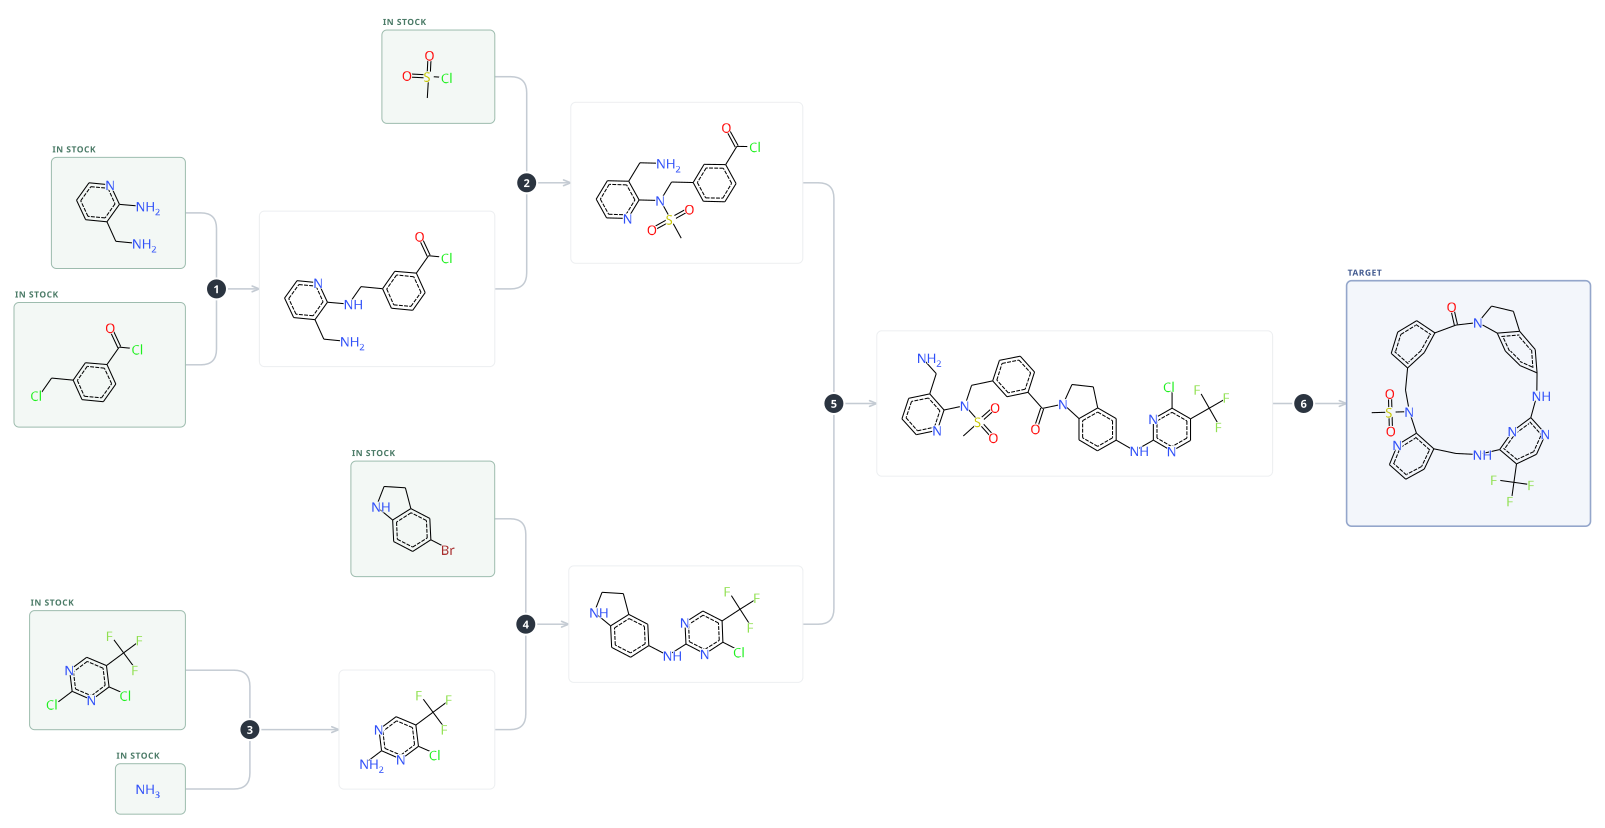

In [16]:
from IPython.display import display

from synplan.chem.reaction.routes import Route
from synplan.utils.visualisation import route_rule_labels

print(route_rule_labels(tree, route_id))
display(Route.from_tree(tree, route_id))

## 7. The same search without the priority set

The comparison run keeps every other setting and drops the priority path.

In [17]:
from synplan.utils.frames import tree_stats_frame

baseline_config = tree_config.model_copy(update={"use_priority": False})

baseline_tree = Tree(
    target=target_molecule,
    config=baseline_config,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    expansion_function=policy_function,
    evaluation_function=evaluation_function,
)

baseline_tree.run()

tree_stats_frame({"synthon priority": tree, "policy only": baseline_tree})[
    [
        "num_routes",
        "num_nodes",
        "search_time",
        "best_route_score",
        "priority_rules_tried",
        "priority_rules_succeeded",
        "fraction_routes_with_priority",
        "policy_rules_tried",
    ]
].T

  0%|          | 0/100 [00:00<?, ?it/s]

run,synthon priority,policy only
num_routes,4.000000,0.0
num_nodes,2908.000000,3131.0
search_time,7.000000,9.9
best_route_score,0.103294,NaN
priority_rules_tried,205.000000,0.0
priority_rules_succeeded,192.000000,0.0
fraction_routes_with_priority,1.000000,0.0
policy_rules_tried,4450.000000,5000.0


One target and one iteration budget prove nothing general. What the two rows show is where the curated set acts: the priority disconnections take the top of the tree, the policy keeps expanding underneath, and the routes that come out carry names a chemist can check.

## Summary

- `synthon_priority_rules()` returns `{"synthon": [rules]}`, ready for `Tree(priority_rules=...)` with `use_priority=True`.
- Capping is what makes the labels mean something on the reactor path. Without it the fragments include purchasable compounds of the wrong class, and a search happily ends on one. R7.1, R10.1 and R10.2 are still wrong with it.
- A ring rule loads only when it carries a hand-authored reagent form, since capping cannot spell one for a two-bond cut; macrocyclic rules are opt-in.
- Rules that could never fire raise at load time instead of sitting inert in the set.
- Each node stores a source and an index; `rule_name` on the rule object and the `rules.json` record turn that pair back into named chemistry with a provenance a reviewer can act on.